# Iris Classification — End-to-End ML Pipeline
**Flow:** Import → Load → EDA → Preprocessing → Model comparison (CV) → Tuning → Evaluation → Export (`.pkl` + `.csv`) → Reload check

**Outputs (in `artifacts/`):**
- `iris_raw.csv`: the original dataset
- `iris_processed.csv`: the data with encoded labels and a train/test split marker
- `iris_model.pkl`: the full pipeline (scaler + model) plus metadata, ready for FastAPI

## 1. Imports & environment

In [1]:
import os, pickle, json, platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
print(f"Python {platform.python_version()} | sklearn {sklearn.__version__} | pandas {pd.__version__}")

Python 3.14.6 | sklearn 1.8.0 | pandas 3.0.6


## 2. Load data
`sklearn.datasets.load_iris` is the same UCI Iris data that Kaggle hosts (150 rows, 4 features, 3 classes), so no API key is needed.

To use the Kaggle CSV instead, download it and replace this cell with `df = pd.read_csv('Iris.csv').drop(columns='Id')`. Rename the columns to match the ones below.

In [2]:
iris = load_iris(as_frame=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
TARGET_NAMES = [str(n) for n in iris.target_names]          # ['setosa', 'versicolor', 'virginica']

df = iris.frame.copy()
df.columns = FEATURES + ["target"]
df["species"] = df["target"].map(dict(enumerate(TARGET_NAMES)))

# Export raw data
df[FEATURES + ["species"]].to_csv(f"{ARTIFACT_DIR}/iris_raw.csv", index=False)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (150, 6)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int64  
 5   species       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [5]:
print("Missing values per column:\n", df.isna().sum(), sep="")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:\n", df["species"].value_counts(), sep="")

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64

Duplicate rows: 1

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Notes:**
- There are no missing values and the classes are perfectly balanced (50/50/50), so resampling and imputation are unnecessary.
- There is one exact duplicate row. It is a real repeated measurement in the original data, not a data-entry error, so it is kept. Dropping it would change little either way.

In [6]:
df.groupby("species")[FEATURES].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


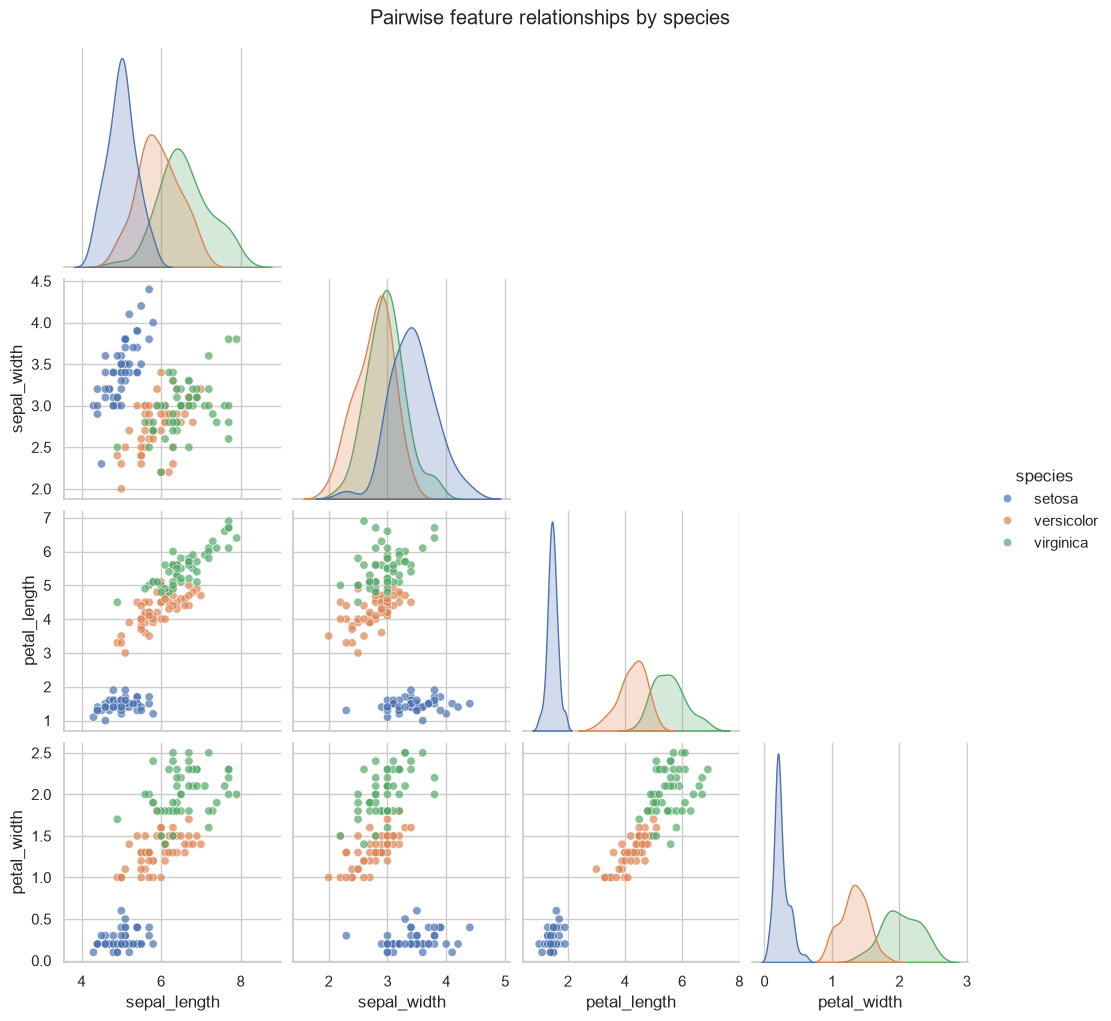

In [7]:
sns.pairplot(df, vars=FEATURES, hue="species", corner=True, plot_kws={"alpha": 0.7})
plt.suptitle("Pairwise feature relationships by species", y=1.02)
plt.show()

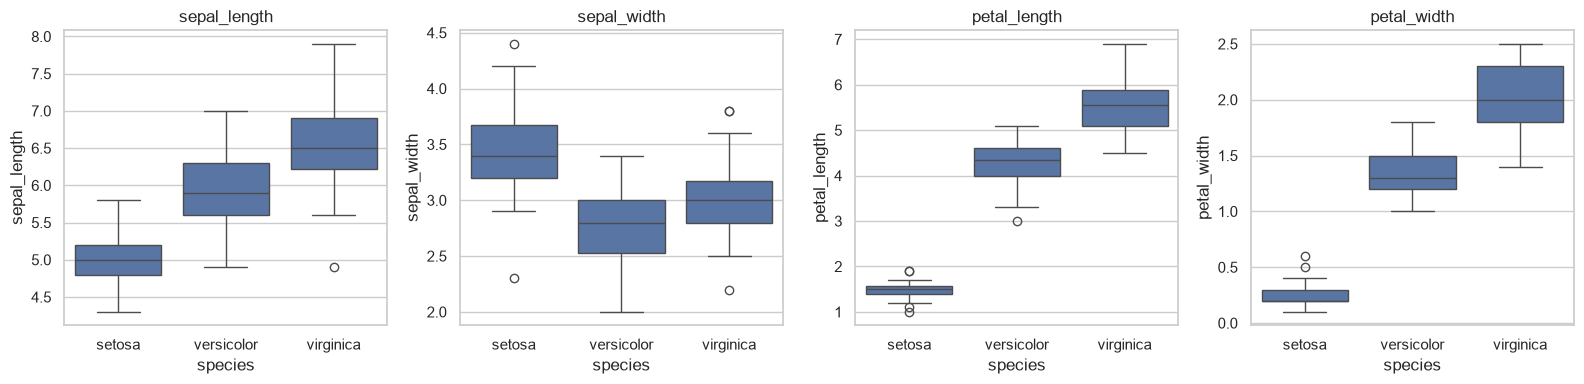

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

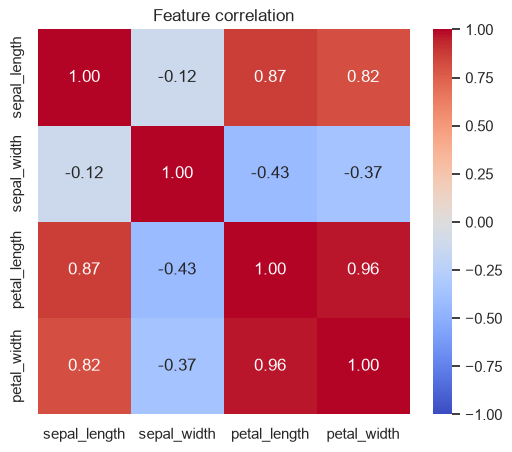

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation")
plt.show()

**EDA takeaways:**
- The petal features separate the classes far better than the sepal features. *Setosa* is linearly separable using petal length alone.
- *Versicolor* and *virginica* overlap slightly, and almost all misclassifications happen there.
- Petal length and petal width are about 0.96 correlated. This is redundant but harmless for these models.
- Features are on different scales (sepal ≈ 4–8 cm vs petal width ≈ 0.1–2.5 cm). Scaling matters for KNN, SVM, and logistic regression.

## 4. Preprocessing
- **Split:** stratified 80/20, so the test set keeps the 1:1:1 class balance.
- **Scaling:** `StandardScaler` goes **inside** the pipeline, not on the full dataset. This avoids leaking test-set statistics into training, and it means the saved `.pkl` scales raw API inputs automatically.
- The label is already integer-encoded (0/1/2), and the mapping is saved with the model.

In [10]:
X = df[FEATURES]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train), "| Test class counts:", np.bincount(y_test))

# Export processed dataset with split marker
processed = df[FEATURES + ["target", "species"]].copy()
processed["split"] = np.where(processed.index.isin(X_train.index), "train", "test")
processed.to_csv(f"{ARTIFACT_DIR}/iris_processed.csv", index=False)
processed["split"].value_counts()

Train: (120, 4) | Test: (30, 4)
Train class counts: [40 40 40] | Test class counts: [10 10 10]


split
train    120
test      30
Name: count, dtype: int64

## 5. Model comparison (stratified 10-fold CV on the training set)
With only 30 test rows, each test error moves accuracy by about 3.3%. Cross-validation gives a more stable ranking.

In [11]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(),
    "SVC":                SVC(probability=True, random_state=RANDOM_STATE),
    "DecisionTree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in candidates.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({"model": name, "cv_mean": scores.mean(), "cv_std": scores.std()})

cv_results = pd.DataFrame(results).sort_values("cv_mean", ascending=False).reset_index(drop=True)
cv_results.round(4)

,model,cv_mean,cv_std
0,SVC,0.9667,0.0408
1,KNN,0.9583,0.0559
2,LogisticRegression,0.9583,0.0417
3,DecisionTree,0.9500,0.0408
4,RandomForest,0.9500,0.0553


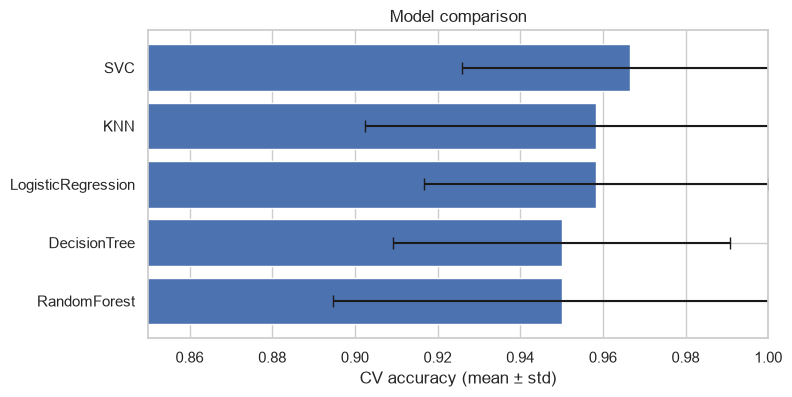

In [12]:
plt.figure(figsize=(8, 4))
plt.barh(cv_results["model"], cv_results["cv_mean"], xerr=cv_results["cv_std"], capsize=4)
plt.xlim(0.85, 1.0)
plt.xlabel("CV accuracy (mean ± std)")
plt.title("Model comparison")
plt.gca().invert_yaxis()
plt.show()

If two models are within one standard deviation of each other, the difference is noise. In that case, choose the simpler or more interpretable model. The next cell tunes the top-ranked model automatically.

## 6. Hyperparameter tuning (top CV model)

In [13]:
param_grids = {
    "LogisticRegression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
    "KNN":                {"clf__n_neighbors": [3, 5, 7, 9, 11, 15], "clf__weights": ["uniform", "distance"]},
    "SVC":                {"clf__C": [0.1, 1, 10, 100], "clf__kernel": ["linear", "rbf"], "clf__gamma": ["scale", 0.1, 0.01]},
    "DecisionTree":       {"clf__max_depth": [2, 3, 4, 5, None], "clf__min_samples_leaf": [1, 2, 5]},
    "RandomForest":       {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 3, 5], "clf__min_samples_leaf": [1, 2]},
}

best_name = cv_results.loc[0, "model"]
base_pipe = Pipeline([("scaler", StandardScaler()), ("clf", candidates[best_name])])

grid = GridSearchCV(base_pipe, param_grids[best_name], cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Selected model :", best_name)
print("Best params    :", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Selected model : SVC
Best params    : {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Best CV accuracy: 0.9667


## 7. Final evaluation on the held-out test set

In [14]:
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=TARGET_NAMES, digits=3))

Test accuracy: 0.9333

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30



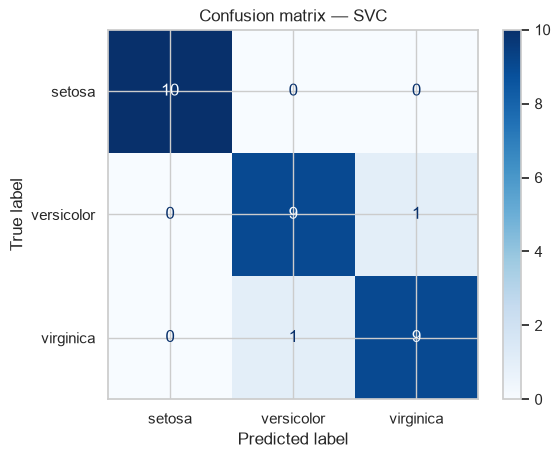

In [15]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(cmap="Blues")
plt.title(f"Confusion matrix — {best_name}")
plt.show()

**Interpretation caveat:** a 100% or 96.7% test score on 30 rows is not evidence that one model beats another. Trust the CV number. Errors, if any, will be versicolor/virginica confusions.

## 8. Refit on all data & export
After model selection is done, refitting on all 150 rows gives the production model slightly more data. The test score above remains the reported estimate.

The `.pkl` stores a **dict**, not a bare model, so the FastAPI app knows the feature order, the label names, and which sklearn version to pin.

In [16]:
final_model = best_model.fit(X, y)

bundle = {
    "model": final_model,                          # full Pipeline: scaler + classifier
    "feature_names": FEATURES,                     # enforce this input order in the API
    "target_names": TARGET_NAMES,                  # index -> label
    "model_name": best_name,
    "best_params": grid.best_params_,
    "metrics": {"cv_accuracy": round(float(grid.best_score_), 4),
                "test_accuracy": round(float(test_acc), 4)},
    "sklearn_version": sklearn.__version__,        # pin this in FastAPI requirements.txt
    "trained_at": datetime.now(timezone.utc).isoformat(),
}

MODEL_PATH = f"{ARTIFACT_DIR}/iris_model.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)

print("Saved:", MODEL_PATH, f"({os.path.getsize(MODEL_PATH)/1024:.1f} KB)")
print(json.dumps({k: v for k, v in bundle.items() if k != "model"}, indent=2, default=str))

Saved: artifacts/iris_model.pkl (5.6 KB)
{
  "feature_names": [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
  ],
  "target_names": [
    "setosa",
    "versicolor",
    "virginica"
  ],
  "model_name": "SVC",
  "best_params": {
    "clf__C": 0.1,
    "clf__gamma": "scale",
    "clf__kernel": "linear"
  },
  "metrics": {
    "cv_accuracy": 0.9667,
    "test_accuracy": 0.9333
  },
  "sklearn_version": "1.8.0",
  "trained_at": "2026-10-06T16:48:12.887380+00:00"
}


## 9. Reload & smoke test (simulates what FastAPI will do)
Only unpickle files you created. `pickle.load` can execute arbitrary code from an untrusted file.

In [17]:
with open(MODEL_PATH, "rb") as f:
    loaded = pickle.load(f)

if loaded["sklearn_version"] != sklearn.__version__:
    print(f"WARNING: model trained on sklearn {loaded['sklearn_version']}, running {sklearn.__version__}")

def predict_one(payload: dict) -> dict:
    """Same logic the FastAPI /predict endpoint will use."""
    row = pd.DataFrame([[payload[f] for f in loaded["feature_names"]]], columns=loaded["feature_names"])
    model = loaded["model"]
    idx = int(model.predict(row)[0])
    proba = model.predict_proba(row)[0]
    return {
        "species": loaded["target_names"][idx],
        "probabilities": {n: round(float(p), 4) for n, p in zip(loaded["target_names"], proba)},
    }

samples = [
    {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2},  # setosa
    {"sepal_length": 6.0, "sepal_width": 2.9, "petal_length": 4.5, "petal_width": 1.5},  # versicolor
    {"sepal_length": 6.9, "sepal_width": 3.1, "petal_length": 5.8, "petal_width": 2.3},  # virginica
]
for s in samples:
    print(s, "->", predict_one(s))

# Sanity check: the reloaded model reproduces the in-memory predictions
assert (loaded["model"].predict(X) == final_model.predict(X)).all()
print("\nReload check passed.")

{'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2} -> {'species': 'setosa', 'probabilities': {'setosa': 0.9794, 'versicolor': 0.0119, 'virginica': 0.0087}}
{'sepal_length': 6.0, 'sepal_width': 2.9, 'petal_length': 4.5, 'petal_width': 1.5} -> {'species': 'versicolor', 'probabilities': {'setosa': 0.0099, 'versicolor': 0.8891, 'virginica': 0.101}}
{'sepal_length': 6.9, 'sepal_width': 3.1, 'petal_length': 5.8, 'petal_width': 2.3} -> {'species': 'virginica', 'probabilities': {'setosa': 0.0031, 'versicolor': 0.0012, 'virginica': 0.9957}}

Reload check passed.


## 10. Artifacts produced
| File | Purpose |
|---|---|
| `artifacts/iris_raw.csv` | Original dataset (features + species) |
| `artifacts/iris_processed.csv` | Features, encoded target, species, train/test split marker |
| `artifacts/iris_model.pkl` | Pipeline + metadata bundle for FastAPI |

**For the FastAPI step:**
- Load the bundle once at startup, not on every request.
- Validate input with a Pydantic model that has the 4 fields, each constrained to `gt=0`.
- Reuse the `predict_one` logic for the endpoint.
- Pin `scikit-learn==<sklearn_version>` in `requirements.txt`.